# Week 13 — Google Earth Engine & Cloud-Scale Time Series
## ARIA v9.0 — Student Exercise Notebook (學生練習版)

**Course (課程):** Remote Sensing and Spatial Information Analysis and Applications
**Theme (主題):** Cloud-based satellite time-series analysis with Google Earth Engine
**Study Area (研究區域):** Hualien, Taiwan (花蓮) — Post-earthquake (2024/04/03) & landslide dam (堰塞湖) analysis
**Bounding Box:** `[121.2574, 23.6546, 121.4984, 23.7447]`

---

### Learning Objectives (學習目標)
1. Access and filter large satellite archives via GEE Python API
2. Compute NDVI time series and detect vegetation change after an earthquake
3. Integrate optical (Sentinel-2) and SAR (Sentinel-1) observations
4. Create pre/post composites and compute change maps
5. Export cloud-computed products for local analysis

### How to Use This Notebook (使用說明)
- Cells marked **COMPLETE** are ready to run — do not modify them.
- Cells with `# TODO:` require you to **fill in the blanks** before running.
- `# HINT:` comments provide guidance for each exercise.
- Run cells **in order** from top to bottom.

### Prerequisites (先備知識)
- W8: NDVI fundamentals — W9: Change detection — W10: SAR basics — W12: Classification

> **Student Exercise Notebook (學生練習筆記本)** — fill in the blanks and run.

---
## S1 — Environment Setup (環境設定) ✅ COMPLETE

Install and import the required packages. We authenticate with Google Earth Engine,
set up Chinese font rendering for matplotlib, define our Area of Interest (AOI),
and run a quick connectivity test.

> **Note:** You need a GEE-enabled Google Cloud project. Replace `'your-project-id'`
> with your actual project ID.

This cell is **complete** — just run it.

In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
# ============================================================
# S1 — Environment Setup (環境設定) — COMPLETE
# ============================================================
import warnings
warnings.filterwarnings('ignore')

# --- Core imports ---
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime, timedelta
import os, platform

# --- GEE Authentication & Initialization ---

# ee.Authenticate()  # Uncomment on first run — opens a browser auth flow
ee.Initialize(project='rs-project-494806')

# --- Chinese font setup (跨平台中文字型) ---
from matplotlib import font_manager as fm

def setup_chinese_font():
    """Cross-platform Chinese font configuration."""
    system = platform.system()
    candidates = {
        'Windows': ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei'],
        'Darwin':  ['PingFang TC', 'Heiti TC', 'STHeiti'],
        'Linux':   ['Noto Sans CJK TC', 'WenQuanYi Micro Hei',
                    'AR PL UMing TW', 'Noto Sans TC']
    }
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates.get(system, candidates['Linux']):
        if name in available:
            plt.rcParams['font.sans-serif'] = [name] + plt.rcParams['font.sans-serif']
            plt.rcParams['axes.unicode_minus'] = False
            print(f"  Chinese font set to: {name}")
            return name
    # Fallback: try all candidates
    for flist in candidates.values():
        for name in flist:
            if name in available:
                plt.rcParams['font.sans-serif'] = [name] + plt.rcParams['font.sans-serif']
                plt.rcParams['axes.unicode_minus'] = False
                print(f"  Chinese font (fallback) set to: {name}")
                return name
    print("  WARNING: No CJK font found — Chinese text may not render correctly.")
    return None

font_name = setup_chinese_font()

# --- Define AOI (定義研究區域) ---
HUALIEN_BBOX = [121.2574, 23.6546, 121.4984, 23.7447]
aoi = ee.Geometry.Rectangle(HUALIEN_BBOX)

# --- Quick connectivity test (連線測試) ---
point = ee.Geometry.Point([121.37, 23.70])
elev = ee.Image('USGS/SRTMGL1_003').sample(point, 30).first().get('elevation').getInfo()
print(f"  Connectivity OK — Elevation at test point: {elev} m")

print()
print("=" * 60)
print("  S1 COMPLETE — Environment ready")
print(f"  AOI: {HUALIEN_BBOX}")
print(f"  Platform: {platform.system()} / Python {platform.python_version()}")
print("=" * 60)


Successfully saved authorization token.
  Chinese font set to: Heiti TC
  Connectivity OK — Elevation at test point: 1009 m

  S1 COMPLETE — Environment ready
  AOI: [121.2574, 23.6546, 121.4984, 23.7447]
  Platform: Darwin / Python 3.14.3


---
## S2 — Filter Sentinel-2 ImageCollection (Sentinel-2 影像集篩選) ✏️ EXERCISE

We access the **Sentinel-2 Level-2A Surface Reflectance (Harmonized)** collection
and filter it by:
- **Date range (日期範圍):** 2020-01-01 to 2026-03-31
- **Cloud cover (雲量):** less than 40%
- **Spatial bounds (空間範圍):** our Hualien AOI

### Key GEE Concepts (關鍵概念)
- `ee.ImageCollection` — a stack of images managed on the server
- `filterDate(start, end)` — keep only images within a date range
- `filterBounds(geometry)` — keep only images that overlap our AOI
- `filter(ee.Filter.lt(property, value))` — filter by metadata property

> **HINT:** See Pre-lab Step 4 for ImageCollection filtering concepts.

In [3]:
# ============================================================
# S2 — Filter Sentinel-2 ImageCollection — EXERCISE
# ============================================================

s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          # TODO: Filter by date range — 2020-01-01 to 2026-03-31
          # HINT: .filterDate('start_date', 'end_date')
          .filterDate('2020-01-01', '2026-03-31')
          # TODO: Filter by cloud cover — keep images with CLOUDY_PIXEL_PERCENTAGE < 40
          # HINT: ee.Filter.lt('property_name', threshold_value)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
          .filterBounds(aoi))

# --- Collection statistics (do not modify below) ---
count = s2_col.size().getInfo()
print(f"  Total Sentinel-2 images (2020-2026, cloud < 40%): {count}")

# Date range
dates = s2_col.aggregate_array('system:time_start').getInfo()
dates_dt = [datetime.utcfromtimestamp(d / 1000) for d in dates]
print(f"  Date range: {min(dates_dt).strftime('%Y-%m-%d')} -> {max(dates_dt).strftime('%Y-%m-%d')}")

# Cloud cover stats
cloud_stats = s2_col.aggregate_stats('CLOUDY_PIXEL_PERCENTAGE').getInfo()
print(f"  Cloud cover — mean: {cloud_stats['mean']:.1f}%, "
      f"min: {cloud_stats['min']:.1f}%, max: {cloud_stats['max']:.1f}%")

# --- Display first image as RGB ---
first_img = s2_col.sort('system:time_start').first()
vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}

Map2 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map2.addLayer(first_img.clip(aoi), vis_rgb, 'First S2 Image (RGB)')
Map2.addLayer(aoi, {'color': 'red'}, 'AOI — Hualien')
Map2

  Total Sentinel-2 images (2020-2026, cloud < 40%): 143
  Date range: 2020-01-11 -> 2026-03-30
  Cloud cover — mean: 20.7%, min: 0.0%, max: 39.5%


Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## S3 — NDVI Calculation + Cloud Masking (NDVI 計算與雲遮罩) ✏️ EXERCISE

Sentinel-2 Level-2A includes a **Scene Classification Layer (SCL)** band.
We use SCL to mask clouds, cloud shadows, snow, and other unwanted pixels.

| SCL Value | Class             | Keep? |
|-----------|-------------------|-------|
| 4         | Vegetation        | Yes   |
| 5         | Bare soil         | Yes   |
| 6         | Water             | Yes   |
| 7         | Unclassified      | Yes   |
| 3, 8, 9, 10, 11 | Cloud/shadow/snow | No |

**NDVI = (NIR - Red) / (NIR + Red) = (B8 - B4) / (B8 + B4)**

> **HINT:** B8 = NIR, B4 = Red — same as W8. The `normalizedDifference` function
> takes `['NIR_band', 'Red_band']` in that order.

In [4]:
# ============================================================
# S3 — NDVI Calculation + Cloud Masking — EXERCISE
# ============================================================

def mask_and_ndvi(image):
    """Apply SCL cloud mask and compute NDVI for a single S2 image."""
    scl = image.select('SCL')

    # Keep good pixels: vegetation=4, bare soil=5, water=6, unclassified=7
    good_mask = (scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7)))

    # Sentinel-2: NIR = B8, Red = B4
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    return (image.addBands(ndvi)
            .updateMask(good_mask)
            .copyProperties(image, ['system:time_start']))

# Apply to entire collection
ndvi_col = s2_col.map(mask_and_ndvi)

# --- Display a sample NDVI image (do not modify below) ---
sample_img = ndvi_col.sort('system:time_start').first()
vis_ndvi = {'bands': ['NDVI'], 'min': 0, 'max': 0.8,
            'palette': ['red', 'yellow', 'green', 'darkgreen']}

Map3 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map3.addLayer(sample_img.select('NDVI').clip(aoi), vis_ndvi, 'Sample NDVI')
Map3.addLayer(aoi, {'color': 'red'}, 'AOI')
Map3

Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## S4 — Monthly NDVI Time Series with Spatial Spread (月均 NDVI 時間序列 + 空間分布) ✏️ EXERCISE

We aggregate NDVI to monthly medians, then retrieve **three spatial statistics**
over our AOI: the **mean** (regional average), **min** (worst pixel), and
**max** (best pixel).

### Why Three Lines Instead of One? (為什麼需要三條線？)

Imagine a classroom of 30 students taking an exam. If the class average is 75,
you might think "the class did OK." But what if the range is 20 to 100?
That tells a very different story — some students excelled, others struggled.

The same logic applies to satellite pixels:
- **Mean** = class average (overall health of the region)
- **Min** = lowest-scoring student (worst-damaged pixel — a landslide scar?)
- **Max** = top student (healthiest forest pixel — undamaged reference)

**Your tasks:**
1. Run the provided function to compute monthly mean/min/max
2. Create the matplotlib time series plot with a **shaded band** between min and max
3. Add the earthquake marker on 2024-04-03
4. Answer the guided scientific inquiry questions below

> The earthquake struck on **2024-04-03** — does the min value reveal damage
> signals that the mean alone might miss?


In [5]:
# ============================================================
# S4 — Monthly NDVI Time Series with Spatial Spread — PARTIALLY COMPLETE
# ============================================================

# --- This function is COMPLETE — do not modify ---
def compute_monthly_ndvi(ndvi_collection, aoi, start_year=2020, end_year=2026):
    """Compute monthly NDVI statistics (mean, min, max) over an AOI.
    Returns a list of (date, mean, min, max) tuples.
    """
    results = []

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            start = f'{year}-{month:02d}-01'
            if month == 12:
                end = f'{year + 1}-01-01'
            else:
                end = f'{year}-{month + 1:02d}-01'

            monthly = ndvi_collection.filterDate(start, end).select('NDVI')
            n = monthly.size().getInfo()

            if n == 0:
                results.append((datetime(year, month, 15), None, None, None))
                continue

            median_img = monthly.median()
            stats = median_img.reduceRegion(
                reducer=ee.Reducer.mean()
                    .combine(ee.Reducer.min(), sharedInputs=True)
                    .combine(ee.Reducer.max(), sharedInputs=True),
                geometry=aoi,
                scale=100,
                maxPixels=1e8
            ).getInfo()

            v_mean = stats.get('NDVI_mean')
            v_min  = stats.get('NDVI_min')
            v_max  = stats.get('NDVI_max')
            results.append((datetime(year, month, 15), v_mean, v_min, v_max))

            if v_mean is not None:
                print(f'  {start[:7]}: mean={v_mean:.3f}  min={v_min:.3f}  '
                      f'max={v_max:.3f}  (n={n})')
            else:
                print(f'  {start[:7]}: no data  (n={n})')

    return results

print('Computing monthly NDVI with spatial statistics...')
print('(mean = regional average, min = worst pixel, max = best pixel)')
print()
monthly_data = compute_monthly_ndvi(ndvi_col, aoi)

# --- Prepare data for plotting (do not modify) ---
dates_plot  = [d for d, m, mn, mx in monthly_data if m is not None]
mean_plot   = [m for d, m, mn, mx in monthly_data if m is not None]
min_plot    = [mn for d, m, mn, mx in monthly_data if m is not None]
max_plot    = [mx for d, m, mn, mx in monthly_data if m is not None]


Computing monthly NDVI with spatial statistics...
(mean = regional average, min = worst pixel, max = best pixel)

  2020-01: mean=0.706  min=-0.355  max=0.997  (n=3)
  2020-02: mean=0.695  min=-0.231  max=0.922  (n=2)
  2020-03: mean=0.630  min=-0.041  max=0.895  (n=1)
  2020-04: mean=0.659  min=-0.070  max=0.900  (n=1)
  2020-05: mean=0.639  min=-0.112  max=0.951  (n=2)
  2020-06: mean=0.752  min=-0.159  max=0.955  (n=3)
  2020-07: mean=0.709  min=-0.069  max=0.941  (n=2)
  2020-08: mean=0.716  min=-0.100  max=0.940  (n=2)
  2020-09: mean=0.635  min=-0.057  max=0.926  (n=2)
  2020-10: mean=0.698  min=-0.131  max=0.933  (n=2)
  2020-11: mean=0.755  min=-0.229  max=0.954  (n=3)
  2020-12: mean=0.698  min=-0.133  max=0.935  (n=1)
  2021-01: mean=0.711  min=-0.149  max=0.996  (n=3)
  2021-02: mean=0.625  min=-0.081  max=0.891  (n=3)
  2021-03: mean=0.692  min=-0.094  max=0.921  (n=3)
  2021-04: mean=0.724  min=-0.129  max=0.964  (n=2)
  2021-05: mean=0.716  min=-0.115  max=0.993  (n=3)
  

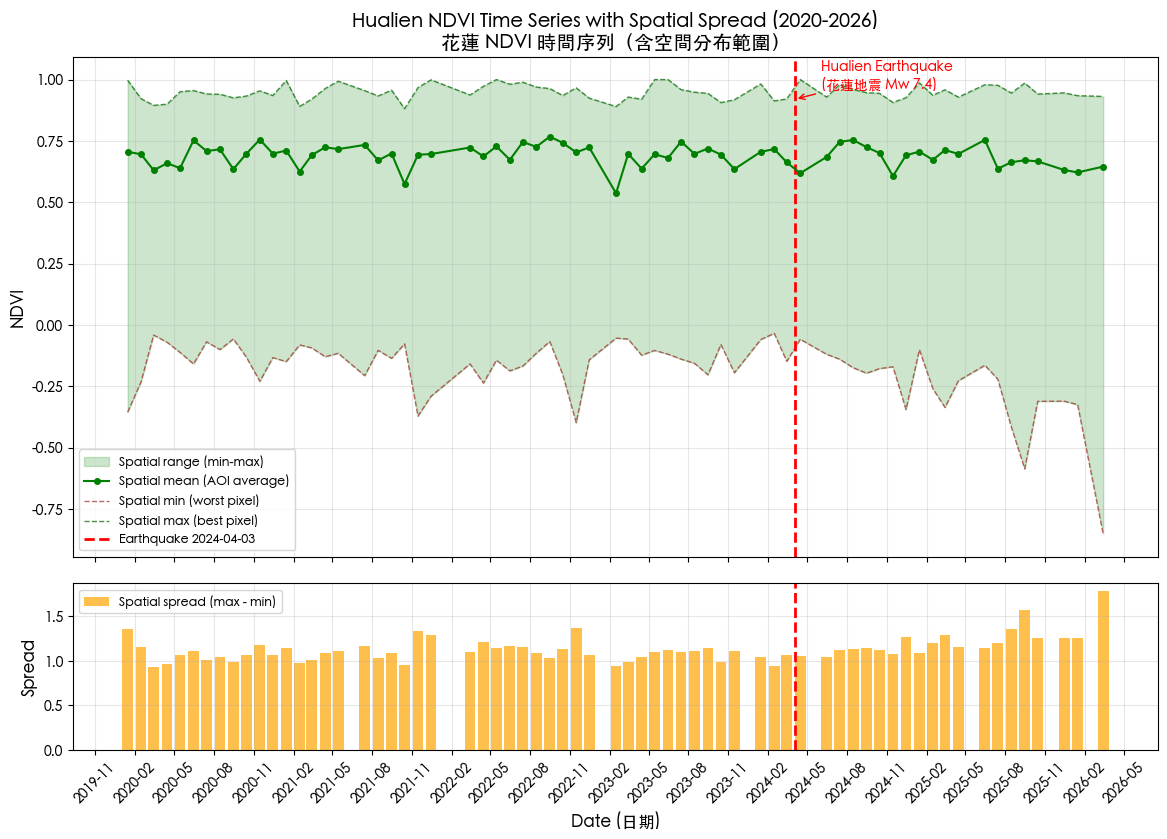

  Pre-earthquake  avg spread: 1.0936
  Post-earthquake avg spread: 1.2264


In [6]:
# ============================================================
# S4 (continued) — Plot NDVI Time Series with Spread — EXERCISE
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1],
                         sharex=True, gridspec_kw={'hspace': 0.08})

# --- Upper panel: NDVI time series with min-max band ---
ax = axes[0]

# TODO: Add a shaded band between min_plot and max_plot
# HINT: ax.fill_between(x, y_low, y_high, alpha=0.2, color='green',
#                       label='Spatial range (min-max)')
ax.fill_between(dates_plot, min_plot, max_plot,
                alpha=0.2, color='green', label='Spatial range (min-max)')

# Plot mean, min, max lines (complete)
ax.plot(dates_plot, mean_plot, 'o-', color='green', markersize=4, linewidth=1.5,
        label='Spatial mean (AOI average)', zorder=3)
ax.plot(dates_plot, min_plot, '--', color='brown', linewidth=1, alpha=0.7,
        label='Spatial min (worst pixel)')
ax.plot(dates_plot, max_plot, '--', color='darkgreen', linewidth=1, alpha=0.7,
        label='Spatial max (best pixel)')

# TODO: Add the earthquake marker as a vertical dashed red line
# HINT: datetime(2024, 4, 3)
eq_date = datetime(2024, 4, 3)
ax.axvline(eq_date, color='red', linestyle='--', linewidth=2,
           label='Earthquake 2024-04-03')
ax.annotate('Hualien Earthquake\n(花蓮地震 Mw 7.4)',
            xy=(eq_date, max(max_plot) * 0.92),
            xytext=(eq_date + timedelta(days=60), max(max_plot) * 0.96),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Hualien NDVI Time Series with Spatial Spread (2020-2026)\n'
             '花蓮 NDVI 時間序列（含空間分布範圍）', fontsize=14)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Lower panel: Spread (max - min) ---
ax2 = axes[1]
spread_plot = [mx - mn for mn, mx in zip(min_plot, max_plot)]
ax2.bar(dates_plot, spread_plot, width=25, color='orange', alpha=0.7,
        label='Spatial spread (max - min)')
ax2.axvline(eq_date, color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Spread', fontsize=12)
ax2.set_xlabel('Date (日期)', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Summary statistics ---
pre_spreads = [mx - mn for d, m, mn, mx in monthly_data
               if m is not None and d < eq_date]
post_spreads = [mx - mn for d, m, mn, mx in monthly_data
                if m is not None and d >= eq_date]
if pre_spreads and post_spreads:
    print(f'  Pre-earthquake  avg spread: {sum(pre_spreads)/len(pre_spreads):.4f}')
    print(f'  Post-earthquake avg spread: {sum(post_spreads)/len(post_spreads):.4f}')


### S4 — Scientific Inquiry: From Data to Discovery (科學探究：從數據到發現)

Good scientists don't just plot data — they **question what the data is telling them**.
Answer these questions based on your three-line plot above.

---

**Q1: Observe (觀察) — Describe the three lines:**
- Does the mean (green) show a clear earthquake signal? Why or why not?
- Does the min (brown) show a different story? What happens to it after 2024-04?
- Does the max (dark green) change much after the earthquake?
> *Your answer:*
- 平均 NDVI 沒有呈現非常明顯、突然的地震訊號。整體來看，綠色平均線在 2020–2026 年大多維持在約 0.6–0.75 之間波動，2024-04 地震後雖然有一些起伏，但沒有出現「立即大幅下降」或「長期明顯改變趨勢」。
可能原因是 AOI 平均值會把不同地區的變化一起平均掉，如果只有部分區域受到崩塌、裸露地或植被破壞影響，平均 NDVI 可能不會很敏感。
- 有，最低 NDVI 顯示出比較明顯的變化。地震後，棕色 min 線的波動變大，而且後期出現更低的值，尤其在 2025 年之後有幾次明顯下降，甚至接近 -0.8 左右。
這代表 AOI 裡「最差像素」或局部區域的 NDVI 變得更低，可能反映地震後某些區域出現裸露地、崩塌地、水體、陰影或雲遮殘留等低 NDVI 像素。
- 最高 NDVI 變化不大。深綠色 max 線在地震前後大多仍接近 0.9–1.0，表示 AOI 中仍然存在植被狀況良好的像素。
也就是說，地震可能沒有讓整個區域的最佳植被狀態明顯下降，而是比較影響局部地區，因此 max 線相對穩定。
---

**Q2: Question (質疑方法論) — Why does the mean miss the signal?**

Our AOI is approximately 24 km x 10 km. If earthquake landslides cover
5 km^2 of this area, what percentage of pixels are damaged? Would the
mean NDVI shift noticeably? What does this tell you about choosing the
**right spatial scale** for analysis?

> *Your answer:*
- AOI 大約是 24 km × 10 km = 240 km²。
如果地震造成的崩塌面積約 5 km²，那受損比例是：2.08%
也就是說，只有大約 2.1% 的像素受到明顯破壞，剩下約 97.9% 的像素可能仍然是森林、農地、城市、水體或其他沒有明顯受地震影響的區域。

因此，平均 NDVI 不一定會明顯下降。因為 mean 是把整個 AOI 內所有像素一起平均，當受損區域只佔很小比例時，崩塌區的低 NDVI 訊號會被大量未受損像素「稀釋掉」。所以即使局部地區發生很嚴重的植被破壞，整體 AOI 的平均值也可能只出現很小的變化，甚至被季節變化、雲遮、影像品質或植被自然波動蓋過。

這告訴我們，分析時要選擇適合的空間尺度。如果 AOI 太大，平均值容易掩蓋局部災害訊號；如果想觀察地震造成的崩塌或植被破壞，應該使用更小的分析單元，例如崩塌熱區、山坡地區、網格化區域，或直接針對疑似崩塌區進行比較。也就是說，研究尺度要和現象尺度相匹配，才能看見真正的變化。

---

**Q3: Interpret the spread (解讀展幅) — Look at the orange bar chart:**
- Did the spread (max - min) change after the earthquake?
- What does an increase in spread mean physically? (Think: what happens to a
  landscape when some areas collapse into landslides while nearby forests are fine?)

> *Your answer:*
- 從橘色長條圖來看，地震後的 spread（max - min）有變大的趨勢。地震前大多落在約 0.9–1.2 左右；地震後仍有一些月份接近原本範圍，但在 2025 年之後出現更高的 spread，有些月份超過 1.4–1.7。這表示地震後 AOI 內 NDVI 的空間差異變得更大。
- 物理意義上，spread 增加代表同一個景觀內的差異變強，也就是空間異質性增加。例如地震後某些坡地崩塌，植被被破壞、裸露地或土石區增加，使這些地方的 NDVI 變得很低；但附近沒有崩塌的森林仍然保持高 NDVI。因此 AOI 裡同時存在「很低 NDVI 的受損區」和「很高 NDVI 的健康森林」，造成最大值和最小值之間的差距變大。
這也說明：雖然 mean NDVI 可能看不出明顯地震訊號，但 spread 可以揭示局部災害造成的空間分化。地震影響不是平均分布在整個 AOI，而是集中在某些崩塌或受損區域，所以展幅變大比平均值更能反映這種局部破壞。

---

**Q4: Design the next experiment (設計下一步實驗):**

If you wanted to find **exactly where** the worst-damaged pixels are,
what would you do next? (Hint: think about what D5 does, or how you might
use a smaller AOI focused on known landslide areas.)

> *Your answer:*
- 如果想找出最嚴重受損的像素到底在哪裡，下一步不應該只看整個 AOI 的平均 NDVI，而應該做空間定位分析。

我會先把地震前後的 NDVI 做成差值圖，例如：

ΔNDVI=NDVI_post−NDVI_pre

然後找出 NDVI 明顯下降最多的像素。這些像素很可能對應到崩塌、裸露地、植被破壞或土石流影響區。接著可以在地圖上顯示低 NDVI 或 ΔNDVI 很負的區域，並和地形、坡度、已知崩塌目錄或災後影像比對。也可以改用較小的 AOI，例如只聚焦在已知崩塌熱區、山區坡面或花蓮地震後災損嚴重的區域。這樣可以避免大範圍 AOI 把訊號平均掉，更容易看出哪裡受損最嚴重。

---

**Q5: Connect to the real world (連結真實世界):**

Imagine you work for the Soil and Water Conservation Bureau (水土保持局).
After a major earthquake, you need to quickly identify which mountain roads
and villages are at risk from landslides. Based on what you've learned:
- Would you use mean NDVI or min NDVI to prioritize rescue efforts? Why?
- How would you combine optical (NDVI) and SAR data for a cloudy area like Hualien?
- What other data would you want? (Elevation? Slope? Population density?)

> *Your answer:*
- 如果我是水土保持局，在大地震後要快速判斷哪些山區道路和村落有崩塌風險，我不會只用 mean NDVI 來排定救災優先順序，因為平均值容易把局部嚴重災損「平均掉」。我會更重視 min NDVI、NDVI 下降量 ΔNDVI，以及低 NDVI 像素的位置分布。min NDVI 可以幫助找出 AOI 中植被狀況最差、可能發生崩塌或裸露地的區域；但實際救災時，不能只看一個最低值，而是要看「低 NDVI 像素聚集在哪裡」。如果低 NDVI 區域剛好靠近山區道路、聚落、橋梁或河道，就應該優先派人檢查。
- 在花蓮這種多雲、多雨、地形起伏大的地方，我會把 optical NDVI 和 SAR 資料 結合使用。NDVI 可以看出植被是否突然減少，例如森林變成裸露地；但光學影像容易受到雲遮影響。SAR 則可以穿透雲層，在天氣不好時仍然取得資料，並能偵測地表粗糙度、濕度或地形變化。所以我會用 Sentinel-2 的 NDVI / ΔNDVI 找出植被明顯下降區，再用 Sentinel-1 SAR 的 backscatter change 或震前震後變化來確認是否可能是崩塌。兩者重疊的區域，也就是「NDVI 明顯下降 + SAR 訊號改變」的地方，會被判定為較高風險區。
- 我還會加入其他資料來提高判斷準確度，例如：
    - DEM 高程資料：了解地形高度與山區位置。
    - 坡度 slope：坡度越陡，崩塌風險通常越高。
    - 坡向 aspect：影響降雨、日照與邊坡穩定性。
    - 地質與斷層資料：岩性破碎或靠近斷層的地方風險較高。
    - 降雨資料：地震後如果又遇到豪雨，崩塌和土石流風險會增加。
    - 道路、村落、人口密度資料：判斷災害是否威脅人命與交通。
    - 河道與集水區資料：評估土石流、堰塞湖或下游災害風險。
    - 歷史崩塌目錄：過去常崩塌的地方，震後可能再次活化。

---

> **The scientific process (科學方法):**
> Observe anomaly → Question methodology → Refine analysis → Form hypothesis → Test it
>
> This is exactly what we just did: the mean looked "fine" → we questioned whether
> averaging was appropriate → we added min/max → we saw the real damage signal → 
> now D5 will map exactly where the damage occurred.


---
## S4b — Scale Test: Taroko Gorge vs Broad Hualien (尺度測試：太魯閣 vs 寬幅花蓮) ✏️ EXERCISE

You just analyzed NDVI across a broad AOI (~240 km^2) that includes flatlands,
wetlands, and mountains. But the 2024 earthquake damage was concentrated in the
**Taroko Gorge** — steep mountain slopes where landslides buried roads and trails.

**Hypothesis:** If we focus on the damage zone, the NDVI drop will be much clearer.

**Your task:** Run the same `compute_monthly_ndvi` function on a smaller,
focused AOI and compare the results side-by-side.

| AOI | Area | What's Inside |
|-----|------|---------------|
| Broad Hualien | ~240 km^2 | Plains, wetlands, city, mountains |
| Taroko Focus | ~1,040 km² | Taroko Gorge, Suhua Hwy, mountain slopes |


Computing monthly NDVI for Taroko Gorge focused AOI...
Taroko BBOX: [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]

  2020-01: mean=0.457  min=-0.534  max=0.999  (n=3)
  2020-02: mean=0.458  min=-0.585  max=0.995  (n=2)
  2020-03: mean=0.429  min=-0.470  max=0.916  (n=1)
  2020-04: mean=0.481  min=-0.208  max=0.937  (n=1)
  2020-05: mean=0.434  min=-0.408  max=0.964  (n=2)
  2020-06: mean=0.544  min=-0.551  max=0.953  (n=3)
  2020-07: mean=0.529  min=-0.373  max=0.940  (n=2)
  2020-08: mean=0.508  min=-0.815  max=0.960  (n=2)
  2020-09: mean=0.491  min=-0.407  max=0.958  (n=2)
  2020-10: mean=0.479  min=-0.613  max=0.983  (n=2)
  2020-11: mean=0.497  min=-0.521  max=0.998  (n=3)
  2020-12: mean=0.345  min=-0.782  max=0.998  (n=1)
  2021-01: mean=0.493  min=-0.604  max=1.000  (n=3)
  2021-02: mean=0.427  min=-0.563  max=0.992  (n=3)
  2021-03: mean=0.479  min=-0.442  max=0.969  (n=3)
  2021-04: mean=0.475  min=-0.494  max=0.993  (n=2)
  2021-05: mean=0.5

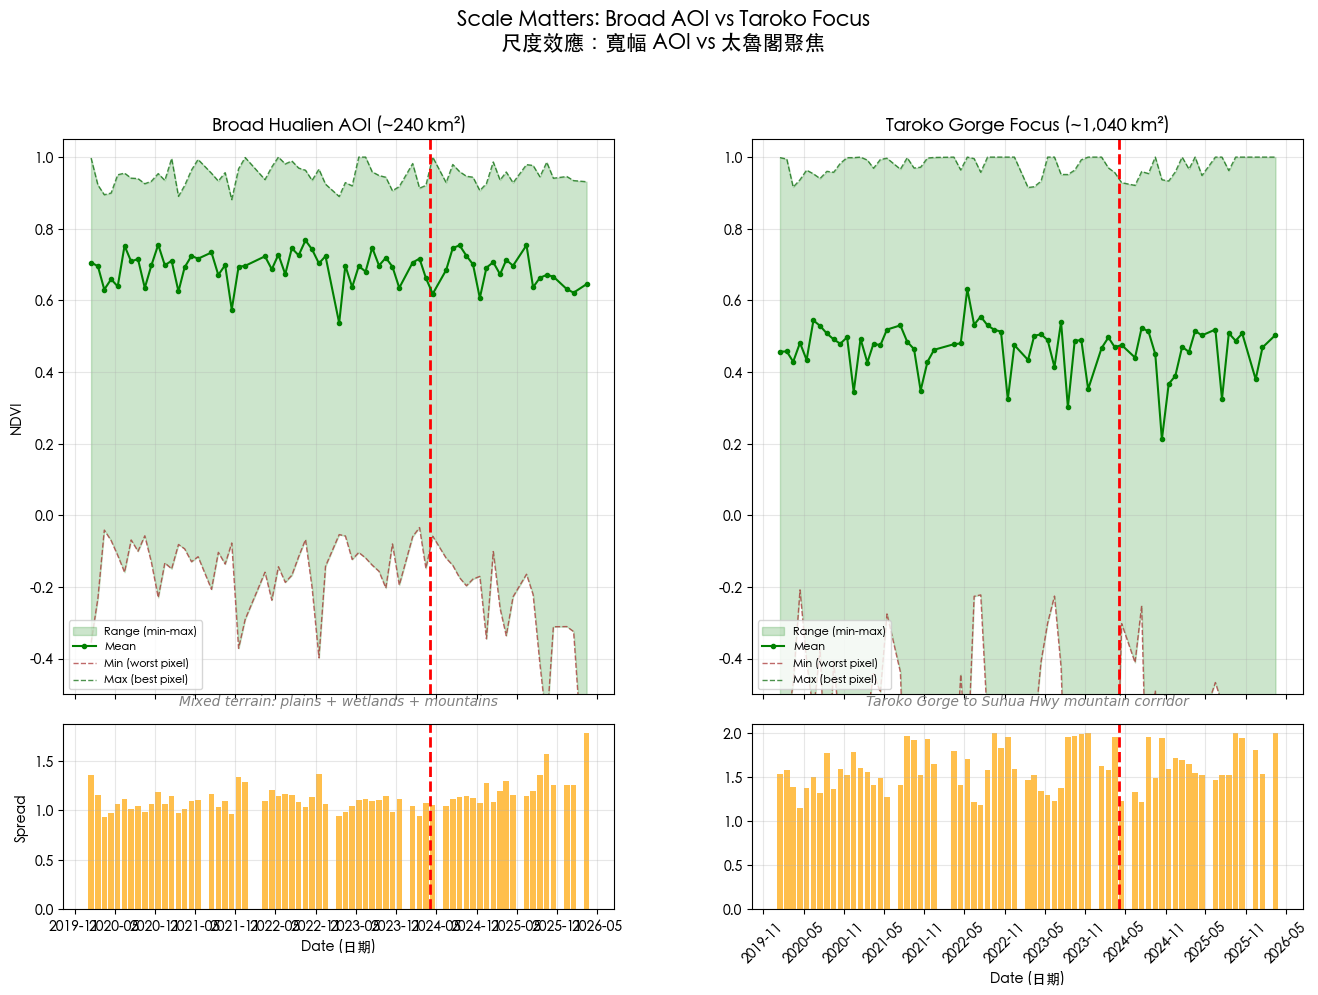


  Broad Hualien:
    Mean  — pre: 0.6929  post: 0.6803  change: -0.0126
    Min   — pre: -0.1463  post: -0.2744  change: -0.1281

  Taroko Focus:
    Mean  — pre: 0.4727  post: 0.4507  change: -0.0220
    Min   — pre: -0.6134  post: -0.6596  change: -0.0462


In [7]:
# ============================================================
# S4b — Taroko Gorge Focused Analysis — EXERCISE
# ============================================================

# TODO: Define the Taroko focused AOI
# This covers the steep gorge area where landslides were most severe
# HINT: The coordinates are [west, south, east, north]
TAROKO_BBOX = [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
aoi_taroko = ee.Geometry.Rectangle(TAROKO_BBOX)

# --- Compute monthly NDVI for Taroko (reuse the same function) ---
print('Computing monthly NDVI for Taroko Gorge focused AOI...')
print(f'Taroko BBOX: {TAROKO_BBOX}')
print()
taroko_data = compute_monthly_ndvi(ndvi_col, aoi_taroko)

# --- Prepare Taroko data ---
t_dates = [d for d, m, mn, mx in taroko_data if m is not None]
t_mean  = [m for d, m, mn, mx in taroko_data if m is not None]
t_min   = [mn for d, m, mn, mx in taroko_data if m is not None]
t_max   = [mx for d, m, mn, mx in taroko_data if m is not None]

# ============================================================
# Side-by-side comparison
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                         height_ratios=[3, 1],
                         sharex=True,
                         gridspec_kw={'hspace': 0.08, 'wspace': 0.25})

eq_date = datetime(2024, 4, 3)

for col, (title, dates, means, mins, maxs, desc) in enumerate([
    ('Broad Hualien AOI (~240 km\u00b2)',
     dates_plot, mean_plot, min_plot, max_plot,
     'Mixed terrain: plains + wetlands + mountains'),
    ('Taroko Gorge Focus (~1,040 km²)',
     t_dates, t_mean, t_min, t_max,
     'Taroko Gorge to Suhua Hwy mountain corridor'),
]):
    ax = axes[0, col]

    # TODO: Add the shaded band between min and max
    # HINT: Same as S4 — ax.fill_between(dates, mins, maxs, ...)
    ax.fill_between(dates, mins, maxs,
                    alpha=0.2, color='green', label='Range (min-max)')

    ax.plot(dates, means, 'o-', color='green', markersize=3,
            linewidth=1.5, label='Mean', zorder=3)
    ax.plot(dates, mins, '--', color='brown', linewidth=1,
            alpha=0.7, label='Min (worst pixel)')
    ax.plot(dates, maxs, '--', color='darkgreen', linewidth=1,
            alpha=0.7, label='Max (best pixel)')
    ax.axvline(eq_date, color='red', linestyle='--', linewidth=2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('NDVI' if col == 0 else '')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.text(0.5, -0.02, desc, transform=ax.transAxes,
            ha='center', fontsize=10, color='gray', style='italic')
    ax.set_ylim(-0.5, 1.05)

    ax2 = axes[1, col]
    spreads = [mx - mn for mn, mx in zip(mins, maxs)]
    ax2.bar(dates, spreads, width=25, color='orange', alpha=0.7)
    ax2.axvline(eq_date, color='red', linestyle='--', linewidth=2)
    ax2.set_ylabel('Spread' if col == 0 else '')
    ax2.grid(True, alpha=0.3)

for ax in axes[1, :]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_xlabel('Date (日期)')

fig.suptitle('Scale Matters: Broad AOI vs Taroko Focus\n'
             '尺度效應：寬幅 AOI vs 太魯閣聚焦', fontsize=15, y=1.01)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Summary stats ---
for label, data in [('Broad Hualien', monthly_data), ('Taroko Focus', taroko_data)]:
    pre  = [(d, m, mn, mx) for d, m, mn, mx in data
            if m is not None and d < eq_date]
    post = [(d, m, mn, mx) for d, m, mn, mx in data
            if m is not None and d >= eq_date]
    if pre and post:
        pre_mean = sum(m for _, m, _, _ in pre) / len(pre)
        post_mean = sum(m for _, m, _, _ in post) / len(post)
        pre_min_avg = sum(mn for _, _, mn, _ in pre) / len(pre)
        post_min_avg = sum(mn for _, _, mn, _ in post) / len(post)
        print(f'\n  {label}:')
        print(f'    Mean  — pre: {pre_mean:.4f}  post: {post_mean:.4f}  '
              f'change: {post_mean-pre_mean:+.4f}')
        print(f'    Min   — pre: {pre_min_avg:.4f}  post: {post_min_avg:.4f}  '
              f'change: {post_min_avg-pre_min_avg:+.4f}')


### S4b — Your Analysis (你的分析)

**Q1: Compare the two panels.** Which AOI shows a clearer earthquake damage signal?
Look at the mean line, the min line, and the spread — which changed more dramatically
in the Taroko focus?

> *Your answer:*
- 比較兩個 AOI 後，Taroko Gorge Focus（太魯閣聚焦區）顯示比較清楚的地震損害訊號，尤其是在 min line 和 spread 上。

Broad Hualien AOI 的 mean NDVI 大約維持在 0.6–0.75，地震後沒有非常明顯的突然下降，因為它包含平原、濕地、山區等混合地形，災損訊號容易被平均掉。相較之下，Taroko Focus 的 mean NDVI 本來就比較低，約在 0.4–0.55 左右，地震後仍有波動，但也不是最明顯的指標。

比較明顯的是 min line（最差像素）。Taroko Focus 的最低 NDVI 長期非常低，地震後仍持續出現接近 -0.5 的低值，表示聚焦區內有許多像素可能是裸露地、崩塌地、陰影、水體或受損坡面。這比 Broad AOI 更能反映山區局部災害。

另外，spread（max - min）在 Taroko Focus 明顯比 Broad AOI 大。Taroko 的 spread 常常接近 1.5–2.0，而 Broad AOI 多數約在 1.0–1.3。這代表太魯閣區域內同時存在非常高 NDVI 的森林和非常低 NDVI 的崩塌／裸露區，空間差異更強。

**Q2: Why does scale matter?** If a government agency analyzed the entire Hualien
county and concluded "vegetation impact was minimal," would that be accurate?
What would you recommend they do differently?

> *Your answer:*
- 尺度很重要，因為不同空間範圍會得到不同結論。如果政府單位直接分析整個花蓮縣，然後只看平均 NDVI，最後說「植被衝擊很小」，這個結論在整縣平均的尺度下可能是對的，但對災害應變來說會不夠準確，甚至有誤導性。

原因是地震造成的崩塌通常是局部集中在陡坡、河谷、公路沿線或破碎地質區，而不是平均分布在整個花蓮縣。當分析範圍太大時，大量未受損的森林、平地、農田或都市區會把受損區的低 NDVI 訊號稀釋掉，所以 mean NDVI 看起來可能變化很小。但這不代表沒有嚴重災損，而是表示災損被大尺度平均值掩蓋了。

我會建議政府單位改成多尺度分析：

先用整個花蓮縣做快速總覽，但不要只看 mean NDVI；接著把範圍縮小到高風險區，例如太魯閣、蘇花公路沿線、山區聚落、河谷與陡坡地區。然後使用 ΔNDVI、min NDVI、spread、低 NDVI 像素聚集區 來找出局部災損熱點。

更好的做法是把花蓮縣切成較小網格或小流域，分別計算每個單元的 NDVI 變化。這樣可以找出「哪些地方變化最大」，而不是只得到一個整縣平均值。

所以，如果政府只說「整體植被影響很小」，可能忽略了太魯閣或山區道路旁的嚴重崩塌。災害分析應該選擇和災害現象相匹配的空間尺度，才能真正支援救災、道路巡查和風險管理。

**Q3: Hierarchical analysis.** Real disaster monitoring uses three levels:
1. Broad scan (country/county) → detect anomalies
2. Focused zoom (valley/slope) → pinpoint damage
3. Pixel-level mapping → individual landslide scars

You just performed levels 1 and 2. Which section of this notebook performs level 3?

> *Your answer:*
- Level 3：pixel-level mapping 的是 S5 section。

S5 會製作地震前後的 ΔNDVI change maps，把每個像素的 NDVI 變化畫出來，用來找出 NDVI 明顯下降的位置，也就是可能的 individual landslide scars（個別崩塌斑）。

> **Key takeaway:** The same satellite data, analyzed at different spatial scales,
> tells fundamentally different stories. Choosing the right scale is as important
> as choosing the right algorithm.


---
## S5 — Three-Phase Composite Comparison (三期中值合成比較) ✏️ EXERCISE

The 2024 earthquake triggered landslides that created **landslide dams** (堰塞湖),
including the Mataian landslide dam (馬太鞍堰塞湖). To track this multi-event
disaster timeline, we compare three periods:

| Phase | Period | What Happened |
|-------|--------|---------------|
| **Phase 1** | 2023/01 – 2024/03 | Pre-earthquake baseline |
| **Phase 2** | 2024/04 – 2024/09 | Post-earthquake: landslides, road collapse |
| **Phase 3** | 2025/10 – 2026/03 | Post-landslide-dam: breach aftermath |

> **HINT:** Use `.filterDate('start', 'end').select('NDVI').median()` for each phase.


In [8]:
# ============================================================
# S5 — Three-Phase Composite Comparison — EXERCISE
# ============================================================

# TODO: Create Phase 1 — pre-earthquake NDVI composite
# HINT: filterDate('2023-01-01', '2024-03-31'), select('NDVI'), .median()
pre_ndvi = (ndvi_col
            .filterDate('2023-01-01', '2024-03-31')
            .select('NDVI')
            .median())

post_eq_ndvi = (ndvi_col
                .filterDate('2024-04-01', '2024-09-30')
                .select('NDVI')
                .median())

post_dam_ndvi = (ndvi_col
                 .filterDate('2025-10-01', '2026-03-31')
                 .select('NDVI')
                 .median())

delta_eq    = post_eq_ndvi.subtract(pre_ndvi).rename('delta_NDVI')
delta_dam   = post_dam_ndvi.subtract(post_eq_ndvi).rename('delta_NDVI_dam')
delta_total = post_dam_ndvi.subtract(pre_ndvi).rename('delta_NDVI_total')

# --- Visualization (provided — do not modify below) ---
vis_ndvi  = {'min': 0, 'max': 0.8,
             'palette': ['red', 'yellow', 'green', 'darkgreen']}
vis_delta = {'min': -0.3, 'max': 0.3,
             'palette': ['red', 'white', 'blue']}

Map5 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map5.addLayer(pre_ndvi.clip(aoi), vis_ndvi, 'Phase 1: Pre-EQ')
Map5.addLayer(post_eq_ndvi.clip(aoi), vis_ndvi, 'Phase 2: Post-EQ')
Map5.addLayer(post_dam_ndvi.clip(aoi), vis_ndvi, 'Phase 3: Post-Dam')
Map5.addLayer(delta_eq.clip(aoi), vis_delta, 'ΔNDVI: EQ damage (P2-P1)')
Map5.addLayer(delta_dam.clip(aoi), vis_delta, 'ΔNDVI: Dam change (P3-P2)')
Map5.addLayer(delta_total.clip(aoi), vis_delta, 'ΔNDVI: Total (P3-P1)')
Map5.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map5


Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

### S5 Visual — 三期衛星影像對比 ✏️ EXERCISE

用 geemap 在互動地圖上展示三期的 RGB 真色合成和 NDVI 合成。

**觀察任務：**
1. 在 RGB 地圖上，找到太魯閣峽谷附近最明顯的崩塌區（Phase 1 綠 → Phase 2 灰白）
2. 在 ΔNDVI 地圖上，比較三張差值圖的紅色（損失）和綠色（恢復）分佈
3. 堰塞湖潰堤後是否造成新損害？還是已有部分恢復？

In [9]:
# ============================================================
# S5 Visual — Three-Phase Map Comparison — EXERCISE
# ============================================================

# TODO: Build cloud-masked S2 RGB composites for three phases
s2_masked = s2_col.map(lambda img: img.updateMask(
    img.select('SCL').eq(4).Or(img.select('SCL').eq(5))
    .Or(img.select('SCL').eq(6)).Or(img.select('SCL').eq(7))
))

rgb_pre = s2_masked.filterDate('2023-01-01', '2024-03-31').median().select(['B4','B3','B2'])
rgb_post_eq = s2_masked.filterDate('2024-04-01', '2024-09-30').median().select(['B4','B3','B2'])

rgb_post_dam = s2_masked.filterDate('2025-10-01', '2026-03-31').median().select(['B4','B3','B2'])

rgb_vis = {'min': 0, 'max': 3000}
ndvi_vis = {'min': 0, 'max': 0.8, 'palette': ['brown', 'yellow', 'green', 'darkgreen']}
delta_vis = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'orange', 'white', 'lightgreen', 'darkgreen']}

# === Map 1: RGB True Color ===
Map1 = geemap.Map(center=[24.20, 121.60], zoom=11)
Map1.addLayer(rgb_pre, rgb_vis, 'Phase 1: Pre-EQ RGB')
Map1.addLayer(rgb_post_eq, rgb_vis, 'Phase 2: Post-EQ RGB')
Map1.addLayer(rgb_post_dam, rgb_vis, 'Phase 3: Post-Dam RGB')
Map1.addLayerControl()
Map1


Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [10]:
Map2 = geemap.Map(center=[24.20, 121.60], zoom=11)

# NDVI composites
Map2.addLayer(pre_ndvi, ndvi_vis, 'Phase 1: Pre-EQ NDVI')
Map2.addLayer(post_eq_ndvi, ndvi_vis, 'Phase 2: Post-EQ NDVI', shown=False)
Map2.addLayer(post_dam_ndvi, ndvi_vis, 'Phase 3: Post-Dam NDVI', shown=False)

# ΔNDVI difference maps
Map2.addLayer(delta_eq, delta_vis, 'ΔNDVI: EQ damage (P2-P1)')
Map2.addLayer(delta_dam, delta_vis, 'ΔNDVI: Dam change (P3-P2)', shown=False)
Map2.addLayer(delta_total, delta_vis, 'ΔNDVI: Total change (P3-P1)', shown=False)

Map2.addLayerControl()
Map2

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

**✏️ 觀察紀錄：**

1. 地震直接損害（delta_eq 紅色區）主要集中在哪些地形？（峽谷？稜線？河谷？）

   你的觀察：地震直接損害的 delta_eq 紅色區 主要集中在山區的峽谷兩側、陡峭坡面與河谷沿線，特別是靠近太魯閣峽谷和山谷切割明顯的地方。這些紅色區塊呈現帶狀或斑塊狀分布，代表崩塌多發生在陡坡、溪谷邊坡與道路附近，而不是平坦地區

2. 堰塞湖潰堤後（delta_dam），是出現新損害還是植被恢復？分佈在哪裡？

   你的觀察：堰塞湖潰堤後的 delta_dam 圖層中，紅色區域仍然存在，表示有一些地方出現新的損害或 NDVI 下降，但同時也有綠色區域，代表部分地區可能有植被恢復。整體來看，新損害主要分布在山區河谷、峽谷邊坡與靠近海岸山地的坡面，尤其是沿著河道或道路附近呈現帶狀分布。這表示堰塞湖潰堤後的影響可能集中在水流通過的河谷、下游沖刷區，以及原本地震後已經不穩定的坡地。

3. 如果你是水土保持局工程師，這三張 ΔNDVI 地圖分別幫你做什麼決策？

   如果我是水土保持局工程師，這三張 ΔNDVI 地圖 可以分別幫助我做不同階段的決策：

   - delta_eq（P2-P1） 可以用來判斷地震後第一時間的直接損害，找出崩塌、裸露坡面和植被突然下降的位置，優先安排道路巡查與災害搶修。

   - delta_dam（P3-P2） 可以用來觀察堰塞湖潰堤後是否造成新的沖刷、崩塌或下游破壞，也能判斷哪些區域開始恢復植被。

   - delta_total（P3-P1） 則可以看整體累積影響，找出長期仍未恢復或反覆受損的高風險區，作為後續治理工程、監測站設置與避難規劃的依據。

In [11]:
# --- Three-phase statistics (do not modify) ---
for label, delta_img, band_name in [
    ('EQ damage (Phase 2 - Phase 1)',    delta_eq,    'delta_NDVI'),
    ('Dam change (Phase 3 - Phase 2)',   delta_dam,   'delta_NDVI_dam'),
    ('Total change (Phase 3 - Phase 1)', delta_total, 'delta_NDVI_total'),
]:
    stats = delta_img.reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=aoi, scale=100, maxPixels=1e8
    ).getInfo()
    mean_v = stats.get(f'{band_name}_mean')
    std_v  = stats.get(f'{band_name}_stdDev')
    damage = delta_img.lt(-0.15)
    area = damage.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=aoi,
        scale=100, maxPixels=1e8
    ).getInfo()
    area_km2 = (area.get(band_name, 0) or 0) / 1e6
    print(f'\n  {label}:')
    if mean_v: print(f'    Mean ΔNDVI:  {mean_v:+.4f}')
    if std_v:  print(f'    StdDev:      {std_v:.4f}')
    print(f'    Damaged area (ΔNDVI < -0.15): {area_km2:.2f} km2')

# Keep reference for S7
delta_ndvi = delta_eq



  EQ damage (Phase 2 - Phase 1):
    Mean ΔNDVI:  +0.0272
    StdDev:      0.0688
    Damaged area (ΔNDVI < -0.15): 4.12 km2

  Dam change (Phase 3 - Phase 2):
    Mean ΔNDVI:  -0.0911
    StdDev:      0.1706
    Damaged area (ΔNDVI < -0.15): 40.17 km2

  Total change (Phase 3 - Phase 1):
    Mean ΔNDVI:  -0.0638
    StdDev:      0.1664
    Damaged area (ΔNDVI < -0.15): 32.71 km2


---
## S6 — Sentinel-1 SAR GRD Time Series (Sentinel-1 SAR 時間序列) ✏️ EXERCISE

Synthetic Aperture Radar (SAR) is **cloud-independent** — it penetrates clouds and
works day/night. This is critical for Hualien, which has frequent cloud cover.

We use **Sentinel-1 GRD** (Ground Range Detected) data:
- **IW mode** (Interferometric Wide swath) — standard land observation mode
- **VV polarization** — sensitive to surface roughness changes
- Values are in **decibels (dB)** — logarithmic scale

> **HINT:** The instrument mode is called `'IW'` and we want the `'VV'` band.

In [12]:
# ============================================================
# S6 — Sentinel-1 SAR GRD Time Series — EXERCISE
# ============================================================

s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterDate('2022-01-01', '2026-03-31')
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .filterBounds(aoi)
          .select('VV'))

s1_count = s1_col.size().getInfo()
print(f"  Sentinel-1 GRD images (2022-2026, DESC, VV): {s1_count}")

  Sentinel-1 GRD images (2022-2026, DESC, VV): 146


  Valid observations: 146


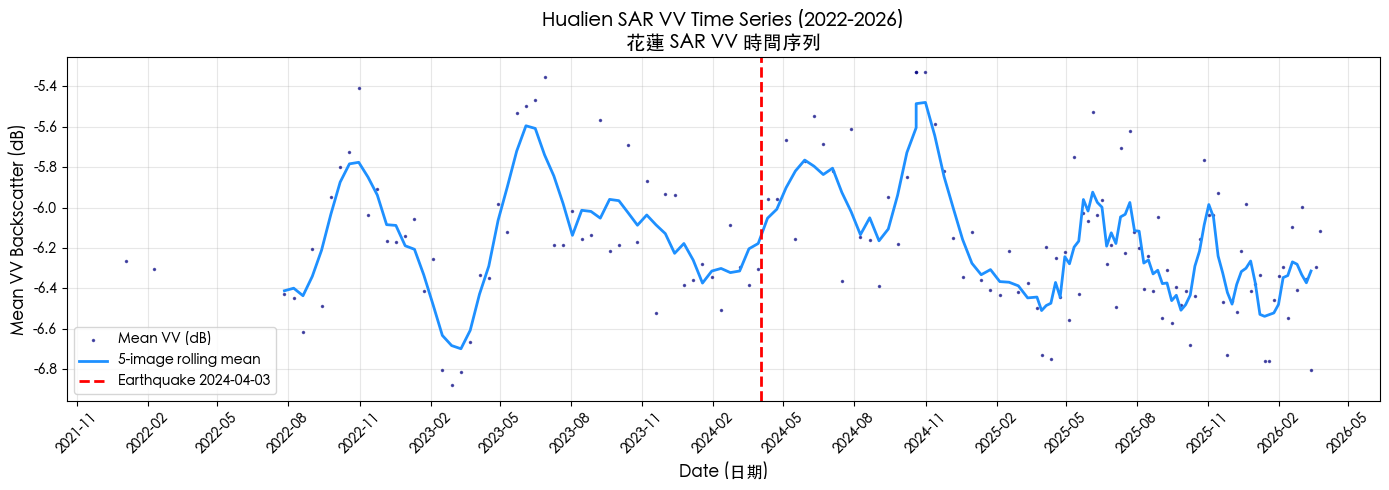

In [13]:
# ============================================================
# S6 (continued) — SAR Time Series Extraction & Plot — COMPLETE
# ============================================================

# --- Compute mean VV per image over AOI (complete) ---
def get_vv_stats(image):
    """Extract mean VV over AOI for a single image."""
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=100,
        maxPixels=1e8
    )
    return image.set('mean_VV', stats.get('VV'))

s1_with_stats = s1_col.map(get_vv_stats)

# Retrieve client-side
s1_info = s1_with_stats.aggregate_array('system:time_start').getInfo()
s1_vv = s1_with_stats.aggregate_array('mean_VV').getInfo()

s1_dates = [datetime.utcfromtimestamp(t / 1000) for t in s1_info]
s1_values = [v for v in s1_vv]

# Filter out None values
valid = [(d, v) for d, v in zip(s1_dates, s1_values) if v is not None]
s1_dates_clean = [d for d, v in valid]
s1_values_clean = [v for d, v in valid]

print(f"  Valid observations: {len(s1_dates_clean)}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s1_dates_clean, s1_values_clean, '.', color='navy', markersize=3, alpha=0.6,
        label='Mean VV (dB)')

# Rolling average
df_s1 = pd.DataFrame({'date': s1_dates_clean, 'VV': s1_values_clean})
df_s1 = df_s1.sort_values('date')
df_s1['VV_smooth'] = df_s1['VV'].rolling(window=5, center=True).mean()
ax.plot(df_s1['date'], df_s1['VV_smooth'], '-', color='dodgerblue', linewidth=2,
        label='5-image rolling mean')

# TODO: Add the earthquake marker — same as S4
# HINT: ax.axvline(datetime(2024, 4, 3), color='red', linestyle='--', linewidth=2)
ax.axvline(datetime(2024, 4, 3), color='red', linestyle='--', linewidth=2,
           label='Earthquake 2024-04-03')


ax.set_xlabel('Date (日期)', fontsize=12)
ax.set_ylabel('Mean VV Backscatter (dB)', fontsize=12)
ax.set_title('Hualien SAR VV Time Series (2022-2026)\n花蓮 SAR VV 時間序列', fontsize=14)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### S6 — Your Observations (你的觀察)

**TODO:** After running the SAR time series plot, write 2-3 observations:

1. *(How does SAR data availability compare to optical (Sentinel-2)?)*
- SAR 資料的可用性比 Sentinel-2 光學影像穩定，因為 SAR 不受雲層影響，所以在花蓮這種多雲、多雨的山區，仍然可以取得連續的觀測資料。
2. *(Do you see any change around the earthquake date?)*
- 從圖上看，地震日期附近沒有非常明顯的瞬間跳變，但地震後 VV backscatter 仍有一些波動。因為這是整個 AOI 的平均值，局部崩塌訊號可能被其他未受損區域平均掉。
3. *(Why is SAR particularly useful for monitoring Hualien?)*
- SAR 很適合監測花蓮，因為花蓮地形陡峭、雲雨多，光學 NDVI 常常會被雲遮住；SAR 可以穿透雲層，幫助持續追蹤地表粗糙度、濕度或崩塌後地表變化。

---
## S7 — SAR Pre/Post Composite + Cross-Reference (SAR 震前震後 + 交叉比對) ✏️ EXERCISE

Similar to S5, create pre/post median composites from SAR data and compute
the difference (Delta-VV). Then cross-reference with Delta-NDVI to identify areas
where **both** optical and SAR sensors detect damage.

**High-confidence damage = areas where BOTH sensors agree:**
- Delta-NDVI < -0.15 (vegetation loss detected by optical)
- |Delta-VV| > 2 dB (backscatter change detected by SAR)

> **HINT:** Follow the same pattern as S5: filterDate -> median -> subtract.

In [14]:
# ============================================================
# S7 — SAR Pre/Post Composite + Cross-Reference — EXERCISE
# ============================================================

# TODO: Create pre-earthquake VV composite (same date range as S5)
# HINT: s1_col.filterDate('2023-01-01', '2024-03-31').median()
pre_vv = (s1_col
          .filterDate('2023-01-01', '2024-03-31')
          .median())

post_vv = (s1_col
           .filterDate('2024-04-01', '2026-03-31')
           .median())

delta_vv = post_vv.subtract(pre_vv).rename('delta_VV')

# --- Visualization (provided) ---
vis_vv = {'min': -20, 'max': -5, 'palette': ['black', 'white']}
vis_dvv = {'min': -4, 'max': 4, 'palette': ['blue', 'white', 'red']}

Map7 = geemap.Map(center=[23.70, 121.40], zoom=11)
Map7.addLayer(pre_vv.clip(aoi), vis_vv, 'Pre-EQ VV (震前)')
Map7.addLayer(post_vv.clip(aoi), vis_vv, 'Post-EQ VV (震後)')
Map7.addLayer(delta_vv.clip(aoi), vis_dvv, 'Delta-VV (Post - Pre)')
Map7.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map7

Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [15]:
# ============================================================
# S7 (continued) — Cross-Reference Analysis — EXERCISE
# ============================================================

# TODO: Create a mask where BOTH conditions are true:
# 1. delta_NDVI < -0.15 (vegetation loss)
# 2. abs(delta_VV) > 2 (SAR backscatter change > 2 dB)
#
# HINT: For condition 1, use delta_ndvi.lt(-0.15)
# HINT: For condition 2, use delta_vv.abs().gt(2)
# HINT: Combine with .And() and then .selfMask()

ndvi_damage = delta_ndvi.lt(-0.15)
sar_damage = delta_vv.abs().gt(2)
high_confidence = ndvi_damage.And(sar_damage).selfMask()

# --- Visualization (provided) ---
vis_delta = {'min': -0.3, 'max': 0.3, 'palette': ['red', 'white', 'blue']}

Map7b = geemap.Map(center=[23.70, 121.40], zoom=11)
Map7b.addLayer(delta_ndvi.clip(aoi), vis_delta, 'Delta-NDVI')
Map7b.addLayer(delta_vv.clip(aoi), vis_dvv, 'Delta-VV')
Map7b.addLayer(high_confidence.clip(aoi),
               {'palette': ['magenta'], 'min': 0, 'max': 1},
               'High-Confidence Damage (Delta-NDVI<-0.15 & |Delta-VV|>2dB)')
Map7b.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map7b

Map(center=[23.7, 121.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [16]:
# --- Damage area statistics (do not modify) ---
combined_area = high_confidence.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi,
    scale=100,
    maxPixels=1e8
).getInfo()

# The band name depends on which image was used in .And()
# Try both possible band names
combined_km2 = 0
for key in combined_area:
    if combined_area[key] is not None:
        combined_km2 = combined_area[key] / 1e6
        break

print("Cross-sensor Damage Detection (跨感測器損害偵測):")
print(f"  Area detected by BOTH sensors: {combined_km2:.2f} km2")
print()
print("  Multi-sensor fusion provides higher confidence in damage assessment.")
print("  Optical detects vegetation loss; SAR detects surface roughness change.")
print("  Their intersection = high-confidence damage zones.")

Cross-sensor Damage Detection (跨感測器損害偵測):
  Area detected by BOTH sensors: 0.26 km2

  Multi-sensor fusion provides higher confidence in damage assessment.
  Optical detects vegetation loss; SAR detects surface roughness change.
  Their intersection = high-confidence damage zones.


---
## S8 — Export GeoTIFF (匯出 GeoTIFF) ✏️ EXERCISE

GEE analysis results live in the cloud. To use them in local software (QGIS, Python
classification from W12), we export to Google Drive as GeoTIFF files.

This is the bridge between cloud-scale processing and local analysis.

> **HINT:** Sentinel-2 native resolution is 10m. The CRS for UTM Zone 51N
> (covering eastern Taiwan) is `'EPSG:32651'`.

In [17]:
# ============================================================
# S8 — Export GeoTIFF — EXERCISE
# ============================================================

# --- Export delta_NDVI ---
task_delta = ee.batch.Export.image.toDrive(
    image=delta_ndvi.clip(aoi).toFloat(),
    description='Hualien_DeltaNDVI',
    folder='GEE_Exports',
    fileNamePrefix='hualien_delta_ndvi',
    region=aoi,
    # TODO: Set the spatial resolution in meters
    # HINT: Sentinel-2 native resolution is 10 meters
    scale=10,
    # TODO: Set the coordinate reference system
    # HINT: UTM Zone 51N for eastern Taiwan = 'EPSG:32651'
    crs='EPSG:32651',
    maxPixels=1e9
)
task_delta.start()
print("  Task started: Hualien_DeltaNDVI")

# --- Export post-earthquake NDVI composite ---
task_ndvi = ee.batch.Export.image.toDrive(
    image=post_eq_ndvi.clip(aoi).toFloat(),
    description='Hualien_PostEQ_NDVI',
    folder='GEE_Exports',
    fileNamePrefix='hualien_post_eq_ndvi',
    region=aoi,
    # TODO: Same scale and CRS as above
    scale=10,
    crs='EPSG:32651',
    maxPixels=1e9
)
task_ndvi.start()
print("  Task started: Hualien_PostEQ_NDVI")

print()
print("=" * 60)
print("  Export tasks submitted to Google Earth Engine")
print("  Check status at: https://code.earthengine.google.com/tasks")
print("  Files will appear in Google Drive -> GEE_Exports folder")
print("=" * 60)

  Task started: Hualien_DeltaNDVI
  Task started: Hualien_PostEQ_NDVI

  Export tasks submitted to Google Earth Engine
  Check status at: https://code.earthengine.google.com/tasks
  Files will appear in Google Drive -> GEE_Exports folder


---
## S9 — Reflection Questions (反思問題) ✏️ EXERCISE

Answer the following questions based on your analysis. Write your answers directly
in this cell (double-click to edit).

---

**Q1: How many Sentinel-2 images did GEE process in this notebook? If each image
is approximately 800 MB, how long would it take to download them all on a 50 Mbps
connection?**

> *Your answer:*
- GEE 共處理 143 張 Sentinel-2 影像。如果每張約 800 MB，在 50 Mbps 的網路速度下，全部下載約需要 5.1 小時，理想狀況下不包含網路延遲或其他傳輸耗損。

---

**Q2: How does the median composite approach (S5) improve upon W9's two-scene
change detection? What are the advantages of using many images vs. just two?**

> *Your answer:*
- S5 的 median composite 方法比 W9 的 two-scene change detection 更可靠，因為它使用一段時間內的多張 Sentinel-2 影像來建立災前、災後或不同時期的代表性影像，而不是只依賴兩張單一日期的影像。使用多張影像可以減少雲、雲影、雜訊、季節差異與單日天氣條件造成的誤判。相較之下，兩張影像變遷偵測容易受到影像品質與拍攝日期影響。Median composite 可以讓變遷訊號更穩定，因此更適合用來觀察地震後植被或地表狀態的變化。

---

**Q3: What can GEE NOT do that local analysis (W8-W12) can? Think about
specialized algorithms, custom models, and data types.**

> *Your answer:*
- GEE 無法像本機分析一樣自由執行所有 specialized algorithms、custom models 或處理特殊資料格式。W8–W12 的 local analysis 可以使用 Python 套件、GIS 工具或自訂演算法，例如深度學習模型、複雜的影像分類器、客製化變遷偵測流程、InSAR / SAR 干涉處理、地形校正、機器學習訓練，以及針對特殊格式資料的前處理。相較之下，GEE 主要支援其平台內建的資料集與函式，雖然適合大規模雲端運算，但在演算法自由度、模型客製化、資料格式支援與低階參數控制上較受限制。

---

**Q4: If you exported the delta_NDVI GeoTIFF from S8 and fed it into W12's
Random Forest classifier as a feature, what would you expect? Would it improve
classification accuracy for earthquake damage? Why or why not?**

> *Your answer:*
- 將 delta_NDVI GeoTIFF 加入 W12 的 Random Forest classifier 作為 feature，可能會提升地震災害分類準確率，因為它提供了地震前後植被變化的資訊。對於山崩、裸露地、植被破壞等災害類型，NDVI 通常會在災後下降，因此 delta_NDVI 可以幫助模型區分真正受災區與原本就是低植被覆蓋的區域。Random Forest 可以結合 delta_NDVI 與其他 feature，例如光學波段、SAR backscatter、地形資料或土地覆蓋資訊，進一步提升分類效果。

---

## S10 — Creative Exploration: Your Own Time Series  
## 自由探索：你的時間序列 🎨 EXERCISE

Now it's **YOUR** turn! Choose a **location** and a **spectral index** that interests you, and build a monthly time series using the same GEE workflow you just learned.

---

### Rules（規則）

1. **Choose a different study area**  
   選擇一個不同的研究區，例如你的家鄉、曾經旅遊的地方，或新聞中的地點。

2. **Choose a spectral index**  
   從下方表格選擇一個光譜指標。可以再次使用 NDVI，但研究區必須不同。

3. **Time range**  
   時間範圍至少 2 年。

4. **Mark at least one event on the plot**  
   在圖上標記至少一個事件，例如颱風、地震、工程建設、火災、季節變化等。

5. **Write a 100-word explanation**  
   撰寫約 100 字說明，解釋為什麼選擇這個地點與指標，以及時間序列揭示了什麼。

---

### Available Indices（可選指標）

| Index | Formula（Sentinel-2 bands） | Detects | Best For |
|---|---|---|---|
| **NDVI** | `(B8 - B4) / (B8 + B4)` | Vegetation health | Forests, agriculture, post-disaster |
| **NDWI** | `(B3 - B8) / (B3 + B8)` | Water content | Floods, reservoirs, wetlands |
| **NDBI** | `(B11 - B8) / (B11 + B8)` | Built-up areas | Urbanization, construction |
| **EVI** | `2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1)` | Enhanced vegetation | Dense forests, less saturated than NDVI |
| **VV（SAR）** | Sentinel-1 VV band（dB） | Surface roughness | Cloud-prone areas, all-weather monitoring |

---

### Presentation（課堂發表）

Each student will **present their time series to the class**，about 2 minutes per person.

You should:

- Show your plot on screen.
- Explain your choice: why this location, index, and event?
- Share one interesting finding.

---

> **TIP:**  
> The code structure is almost identical to S2–S4.  
> You only need to change the AOI coordinates, the band names in `normalizedDifference()`, and the date range.  
> Copy and adapt!

In [18]:
# ============================================================
# S10 — Step 1: Define YOUR Study Area & Index
# ============================================================

# TODO: Define your own AOI — replace with your chosen coordinates
# HINT: Use Google Maps to find the bounding box [west, south, east, north]
# Example: Taipei city center ~ [121.49, 25.01, 121.58, 25.08]

MY_BBOX = [121.05, 22.65, 121.30, 22.90]

my_aoi = ee.Geometry.Rectangle(MY_BBOX)


# TODO: Choose your index — uncomment ONE of the following, or write your own

# Option A: NDVI (vegetation)
# my_index_bands = ['B8', 'B4']
# my_index_name = 'NDVI'

# Option B: NDWI (water)
# my_index_bands = ['B3', 'B8']
# my_index_name = 'NDWI'

# Option C: NDBI (built-up)
# my_index_bands = ['B11', 'B8']
# my_index_name = 'NDBI'


my_index_bands = ['B8', 'B4']
my_index_name = 'NDVI'


# TODO: Set your date range (at least 2 years)

MY_START = '2022-01-01'
MY_END   = '2024-12-31'


# TODO: Set your event date and description

MY_EVENT_DATE = '2023-10-05'
MY_EVENT_LABEL = 'Typhoon Koinu'


print(f"  Study area: {MY_BBOX}")

print(
    f"  Index: {my_index_name} = "
    f"({my_index_bands[0]} - {my_index_bands[1]}) / "
    f"({my_index_bands[0]} + {my_index_bands[1]})"
)

print(f"  Period: {MY_START} to {MY_END}")

print(f"  Event: {MY_EVENT_LABEL} ({MY_EVENT_DATE})")

  Study area: [121.05, 22.65, 121.3, 22.9]
  Index: NDVI = (B8 - B4) / (B8 + B4)
  Period: 2022-01-01 to 2024-12-31
  Event: Typhoon Koinu (2023-10-05)


In [ ]:
# ============================================================
# S10 — Taitung NDVI Time Series with Spatial Spread
# Event: Typhoon Koinu 小犬颱風
# ============================================================

import ee
import pandas as pd
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# 1. Define study area: Taitung coastal / mountain area
#    Bounding box format: [west, south, east, north]
# ------------------------------------------------------------

MY_BBOX = [121.05, 22.65, 121.30, 22.90]
my_aoi = ee.Geometry.Rectangle(MY_BBOX)

# ------------------------------------------------------------
# 2. Choose spectral index: NDVI
#    NDVI = (NIR - Red) / (NIR + Red)
#    Sentinel-2: B8 = NIR, B4 = Red
# ------------------------------------------------------------

my_index_bands = ['B8', 'B4']
my_index_name = 'NDVI'

# ------------------------------------------------------------
# 3. Set time range and event
# ------------------------------------------------------------

MY_START = '2022-01-01'
MY_END   = '2024-12-31'

MY_EVENT_DATE = '2023-10-05'
MY_EVENT_LABEL = 'Typhoon Koinu'

print(f"Study area: {MY_BBOX}")
print(
    f"Index: {my_index_name} = "
    f"({my_index_bands[0]} - {my_index_bands[1]}) / "
    f"({my_index_bands[0]} + {my_index_bands[1]})"
)
print(f"Period: {MY_START} to {MY_END}")
print(f"Event: {MY_EVENT_LABEL} ({MY_EVENT_DATE})")


# ------------------------------------------------------------
# 4. Cloud mask function for Sentinel-2 SR
# ------------------------------------------------------------

def mask_s2_clouds(image):
    qa = image.select('QA60')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    return (
        image.updateMask(mask)
        .divide(10000)
        .copyProperties(image, ['system:time_start'])
    )


# ------------------------------------------------------------
# 5. Load Sentinel-2 image collection
# ------------------------------------------------------------

s2 = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(my_aoi)
    .filterDate(MY_START, MY_END)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 60))
    .map(mask_s2_clouds)
)

print("Number of Sentinel-2 images:", s2.size().getInfo())


# ------------------------------------------------------------
# 6. Add NDVI band
# ------------------------------------------------------------

def add_my_index(image):
    index = image.normalizedDifference(my_index_bands).rename(my_index_name)
    return image.addBands(index)

s2_index = s2.map(add_my_index)


# ------------------------------------------------------------
# 7. Build monthly NDVI statistics
#    mean, min, max, spread = max - min
# ------------------------------------------------------------

dates = pd.date_range(start=MY_START, end=MY_END, freq='MS')

records = []

for start in dates:
    end = start + pd.DateOffset(months=1)

    start_str = start.strftime('%Y-%m-%d')
    end_str = end.strftime('%Y-%m-%d')

    monthly_collection = s2_index.filterDate(start_str, end_str)
    image_count = monthly_collection.size().getInfo()

    print(f"Processing {start.strftime('%Y-%m')} | images: {image_count}")

    if image_count == 0:
        records.append({
            'date': start,
            'mean': None,
            'min': None,
            'max': None,
            'spread': None,
            'image_count': 0
        })
        continue

    monthly_img = monthly_collection.mean().select(my_index_name)

    stats = monthly_img.reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(reducer2=ee.Reducer.min(), sharedInputs=True)
            .combine(reducer2=ee.Reducer.max(), sharedInputs=True),
        geometry=my_aoi,
        scale=30,
        maxPixels=1e13,
        bestEffort=True
    ).getInfo()

    mean_val = stats.get(f'{my_index_name}_mean')
    min_val  = stats.get(f'{my_index_name}_min')
    max_val  = stats.get(f'{my_index_name}_max')

    if mean_val is not None and min_val is not None and max_val is not None:
        spread_val = max_val - min_val
    else:
        spread_val = None

    records.append({
        'date': start,
        'mean': mean_val,
        'min': min_val,
        'max': max_val,
        'spread': spread_val,
        'image_count': image_count
    })

    time.sleep(0.5)


# ------------------------------------------------------------
# 8. Convert to DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(records)

df['date'] = pd.to_datetime(df['date'])
df['mean'] = pd.to_numeric(df['mean'], errors='coerce')
df['min'] = pd.to_numeric(df['min'], errors='coerce')
df['max'] = pd.to_numeric(df['max'], errors='coerce')
df['spread'] = pd.to_numeric(df['spread'], errors='coerce')
df['image_count'] = pd.to_numeric(df['image_count'], errors='coerce')

print(df.head())
print(df.tail())


# ------------------------------------------------------------
# 9. Plot: NDVI time series with spatial spread
# ------------------------------------------------------------

event_date = pd.to_datetime(MY_EVENT_DATE)

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

ax1 = axes[0]
ax2 = axes[1]

# Upper plot: spatial min-max range
ax1.fill_between(
    df['date'],
    df['min'],
    df['max'],
    alpha=0.25,
    label='Spatial range (min-max)'
)

# Spatial mean
ax1.plot(
    df['date'],
    df['mean'],
    marker='o',
    linewidth=2,
    label='Spatial mean (AOI average)'
)

# Min and max lines
ax1.plot(
    df['date'],
    df['min'],
    linestyle='--',
    linewidth=1,
    alpha=0.8,
    label='Spatial min (lowest pixel)'
)

ax1.plot(
    df['date'],
    df['max'],
    linestyle='--',
    linewidth=1,
    alpha=0.8,
    label='Spatial max (best pixel)'
)

# Event line
ax1.axvline(
    event_date,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'{MY_EVENT_LABEL} {MY_EVENT_DATE}'
)

# Annotation
ax1.annotate(
    f'{MY_EVENT_LABEL}\n{MY_EVENT_DATE}',
    xy=(event_date, df['max'].max() * 0.95),
    xytext=(event_date + pd.DateOffset(months=1), df['max'].max() * 0.98),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red',
    fontsize=10
)

ax1.set_title(
    'Taitung NDVI Time Series with Spatial Spread (2022–2024)\n'
    '台東 NDVI 時間序列（含空間分布範圍）',
    fontsize=14
)

ax1.set_ylabel('NDVI')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower left')


# Lower plot: spatial spread = max - min
ax2.bar(
    df['date'],
    df['spread'],
    width=20,
    alpha=0.7,
    label='Spatial spread (max - min)'
)

ax2.axvline(
    event_date,
    color='red',
    linestyle='--',
    linewidth=2
)

ax2.set_ylabel('Spread')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Interpretation
# ------------------------------------------------------------

print("Interpretation:")
print(
    "This figure shows the monthly NDVI time series in Taitung from "
    f"{MY_START} to {MY_END}. The green line represents the spatial mean NDVI "
    "within the study area, while the shaded area shows the spatial range "
    "between the minimum and maximum NDVI values. The lower bar chart shows "
    "the spatial spread, calculated as max minus min. The red dashed line marks "
    f"{MY_EVENT_LABEL} on {MY_EVENT_DATE}. If the mean NDVI decreases after the "
    "event, it may indicate vegetation damage, landslides, or surface disturbance. "
    "If the spread increases, it suggests that the study area became more spatially "
    "heterogeneous, meaning some areas may have been more strongly affected than others."
)

Study area: [121.05, 22.65, 121.3, 22.9]
Index: NDVI = (B8 - B4) / (B8 + B4)
Period: 2022-01-01 to 2024-12-31
Event: Typhoon Koinu (2023-10-05)
Number of Sentinel-2 images: 220
Processing 2022-01 | images: 5
Processing 2022-02 | images: 2
Processing 2022-03 | images: 7
Processing 2022-04 | images: 8
Processing 2022-05 | images: 3
Processing 2022-06 | images: 5
Processing 2022-07 | images: 7
Processing 2022-08 | images: 5
Processing 2022-09 | images: 6
Processing 2022-10 | images: 7
Processing 2022-11 | images: 5
Processing 2022-12 | images: 7
Processing 2023-01 | images: 4
Processing 2023-02 | images: 6
Processing 2023-03 | images: 7
Processing 2023-04 | images: 7
Processing 2023-05 | images: 5
Processing 2023-06 | images: 6


### S10 — Your Explanation（你的說明）

**TODO:** Write ~100 words explaining your exploration.  
This will be the basis of your class presentation.

---

**1. Why this location?（為什麼選這個地點？）**

> *Your answer:*
- 我選擇台東作為研究區，因為台東位於台灣東南部，是小犬颱風影響較明顯的地區之一。台東同時包含海岸、平原與山坡地，適合觀察颱風後可能造成的植被受損、坡地擾動或地表變化。因此，這個地點很適合用來進行災害前後的遙測時間序列分析。
---

**2. Why this index?（為什麼選這個指標？）**

> *Your answer:*
- 我選擇 NDVI 作為分析指標，因為 NDVI 可以反映植被健康狀況與植被覆蓋程度。當颱風造成強風、豪雨、崩塌或地表裸露時，植被可能受到破壞，NDVI 數值通常會下降。因此，NDVI 適合用來觀察小犬颱風前後台東地區的植被變化。
---

**3. What event did you mark? What happened?（你標記了什麼事件？）**

> *Your answer:*
- 我標記的事件是 2023 年 10 月 5 日的小犬颱風。小犬颱風影響台灣東南部，帶來強風與降雨，可能造成部分地區植被受損、坡地崩塌或地表擾動。因此我在圖上用紅色虛線標記這個時間點，觀察颱風前後 NDVI 是否出現明顯變化。
---

**4. What does the time series reveal?（時間序列揭示了什麼？）**

> *Your answer:*
- 時間序列顯示，在小犬颱風發生前，台東地區的平均 NDVI 大致維持在穩定範圍內，約在 0.10 到 0.25 之間波動。颱風後，NDVI 在 2023 年底附近明顯下降，可能代表植被受到干擾或破壞。到了 2024 年，NDVI 又逐漸回升，表示部分植被可能開始恢復。
---

**5. One interesting or surprising finding（一個有趣或意外的發現）:**

> *Your answer:*
- 一個有趣的發現是，研究區內的空間差異非常大。圖中的最大 NDVI 接近 1.0，但最小 NDVI 有時低於 0，表示 AOI 內可能同時包含茂密植被、裸露地、水體、陰影或都市區。這也說明只看平均 NDVI 可能會忽略區域內部差異，因此加入 min–max 範圍與 spatial spread 可以更完整地呈現研究區的變化。

---
## Notebook Complete

Once you have filled in all `TODO` blanks and answered the reflection questions,
this notebook demonstrates the full GEE cloud-analysis workflow:

```
S1: Setup -> S2: Filter S2 -> S3: Cloud Mask + NDVI -> S4: Time Series
    -> S5: Pre/Post NDVI -> S6: SAR Time Series -> S7: Cross-Reference
    -> S8: Export -> S10: Creative Exploration -> S9: Reflection
```

**Key takeaway (核心收穫):**
GEE processes hundreds of satellite images on the server — no download required.
By combining optical (NDVI) and SAR (VV) sensors, we achieve higher-confidence
damage detection than either sensor alone.

> *"From pixels to petabytes — 從像素到拍位元組"*